<a href="https://colab.research.google.com/github/AmanuelDaget/YOLOv12-Object-Recognition-from-Remote-Sensing-images/blob/main/YOLOv12_Object_Recognition_from_Remote_Sensing_images_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Object Recognition using YOLOv12 from Remote Sensing images**

**Install important libraries**

In [1]:
!pip install ultralytics torchvision pyyaml opencv-python -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.8 MB/s eta 0:00:00


**Import libraries**

In [4]:
import os, shutil, yaml, random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from ultralytics import YOLO
from google.colab import drive
import cv2
import numpy as np
from tqdm import tqdm
import collections

from pathlib import Path

**MOUNT GOOGLE DRIVE**

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


**CONFIG**

In [6]:
DRIVE = '/content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Object-detection-using-YOLOv12'
PREP = "/content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Object-detection-using-YOLOv12/Preprocessed"
NUM_CLASSES = 15
CLASS_NAMES = [
    "car","truck","van","long_vehicle","bus",
    "airliner","propeller_aircraft","trainer_aircraft",
    "chartered_aircraft","fighter_aircraft",
    "others","stair_truck","pushback_truck",
    "helicopter","boat"
]

**DATASET PREPARATION**

**Apply CLAHE**

In [7]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

for split in ["training", "test"]:
    dst_imgs = Path(f"{PREP}/{split}/images")
    dst_lbls = Path(f"{PREP}/{split}/labels")
    dst_imgs.mkdir(parents=True, exist_ok=True)

    imgs = list(Path(f"{DRIVE}/{split}/images").glob("*"))
    for p in imgs:
        img = cv2.imread(str(p))
        if img is not None:
            cv2.imwrite(str(dst_imgs / p.name), apply_clahe(img))

    if dst_lbls.exists(): shutil.rmtree(dst_lbls)
    shutil.copytree(f"{DRIVE}/{split}/labels", dst_lbls)
    print(f"  {split}: {len(imgs)} images processed → {dst_imgs}")

  training: 4000 images processed → /content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Object-detection-using-YOLOv12/Preprocessed/training/images
  test: 1000 images processed → /content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Object-detection-using-YOLOv12/Preprocessed/test/images


**Sample Image Before / after comparison**

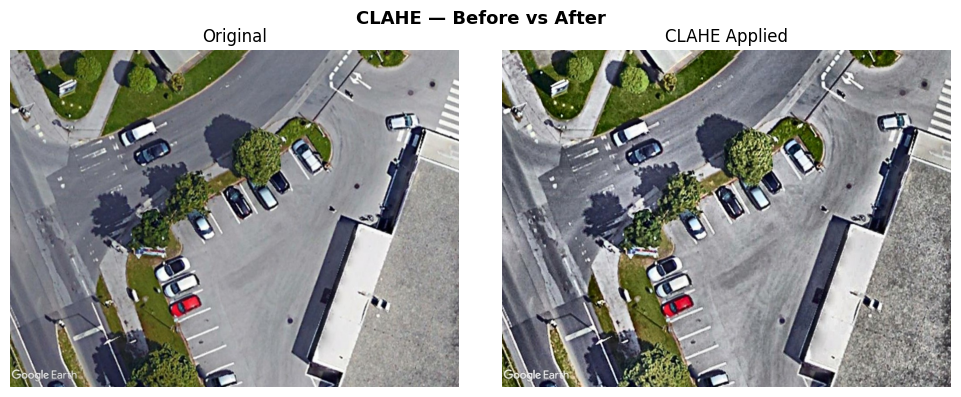

  Saved → clahe_compare.png


In [10]:
sample  = list(Path(f"{DRIVE}/training/images").glob("*"))[0]
orig    = cv2.imread(str(sample))
clahe   = cv2.imread(str(Path(f"{PREP}/training/images") / sample.name))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("CLAHE — Before vs After", fontsize=13, fontweight="bold")
axes[0].imshow(cv2.cvtColor(orig,  cv2.COLOR_BGR2RGB)); axes[0].set_title("Original");      axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(clahe, cv2.COLOR_BGR2RGB)); axes[1].set_title("CLAHE Applied"); axes[1].axis("off")
plt.tight_layout()
plt.savefig(f"{PREP}/clahe_compare.png", dpi=150); plt.show()
print("  Saved → clahe_compare.png")

Tiling

In [13]:
def read_labels(p):
    if not Path(p).exists(): return []
    rows = []
    for line in Path(p).read_text().splitlines():
        line = line.strip()
        if not line: continue
        r = line.split()
        if len(r) == 5:
            rows.append(tuple([int(r[0])] + list(map(float, r[1:]))))
    return rows

**Split Training set to Train/Val**

  Train: 3600 tiles
  Val  : 400 tiles
  Test : 1000 tiles


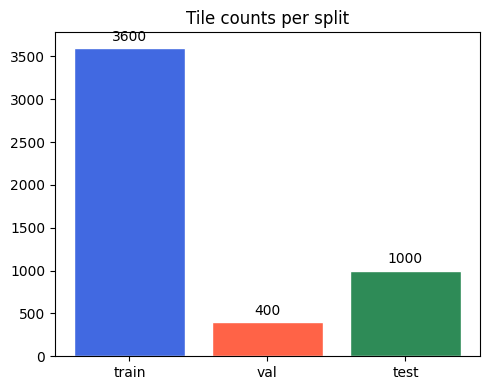

  Saved → split_counts.png


In [14]:
random.seed(42)
src_imgs = Path(PREP)/'training'/'images'
src_lbls = Path(PREP)/'training'/'labels'

for d in ['train', 'val']:
    (Path(PREP)/d/'images').mkdir(parents=True, exist_ok=True)
    (Path(PREP)/d/'labels').mkdir(parents=True, exist_ok=True)

all_stems = [f.stem for f in src_imgs.glob('*.jpg')]

if len(all_stems) == 0:
    print("  ⚠ training/images is empty — split already done or tiling not run")
else:
    val_stems   = set(random.sample(all_stems, int(len(all_stems) * 0.1)))
    train_stems = set(all_stems) - val_stems

    for stem in all_stems:
        dest = 'val' if stem in val_stems else 'train'
        shutil.move(str(src_imgs/f"{stem}.jpg"), Path(PREP)/dest/'images'/f"{stem}.jpg")
        lbl = src_lbls/f"{stem}.txt"
        if lbl.exists():
            shutil.move(str(lbl), Path(PREP)/dest/'labels'/f"{stem}.txt")

    print(f"  Train: {len(train_stems)} tiles")
    print(f"  Val  : {len(val_stems)} tiles")
    print(f"  Test : {len(list((Path(PREP)/'test'/'images').glob('*.jpg')))} tiles")

# ── SPLIT TILE COUNT SUMMARY
split_counts = {
    'train': len(list((Path(PREP)/'train'/'images').glob('*.jpg'))),
    'val'  : len(list((Path(PREP)/'val'  /'images').glob('*.jpg'))),
    'test' : len(list((Path(PREP)/'test' /'images').glob('*.jpg'))),
}
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(split_counts.keys(), split_counts.values(),
              color=['royalblue', 'tomato', 'seagreen'], edgecolor='white')
ax.bar_label(bars, fmt='%d', fontsize=10, padding=3)
ax.set_title('Tile counts per split', fontsize=12)
plt.tight_layout()
plt.savefig(f"{PREP}/split_counts.png", dpi=150); plt.show()
print("  Saved → split_counts.png")

**Yaml file**

In [15]:
yaml_path = f"{PREP}/simd.yaml"
with open(yaml_path, "w") as f:
    yaml.dump({
        "path" : PREP,
        "train": "train/images",
        "val"  : "val/images",
        "test" : "test/images",
        "nc"   : NUM_CLASSES,
        "names": CLASS_NAMES,
    }, f)
print(f"  Saved → {yaml_path}")

  Saved → /content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Object-detection-using-YOLOv12/Preprocessed/simd.yaml


**CLASS DISTRIBUTION**

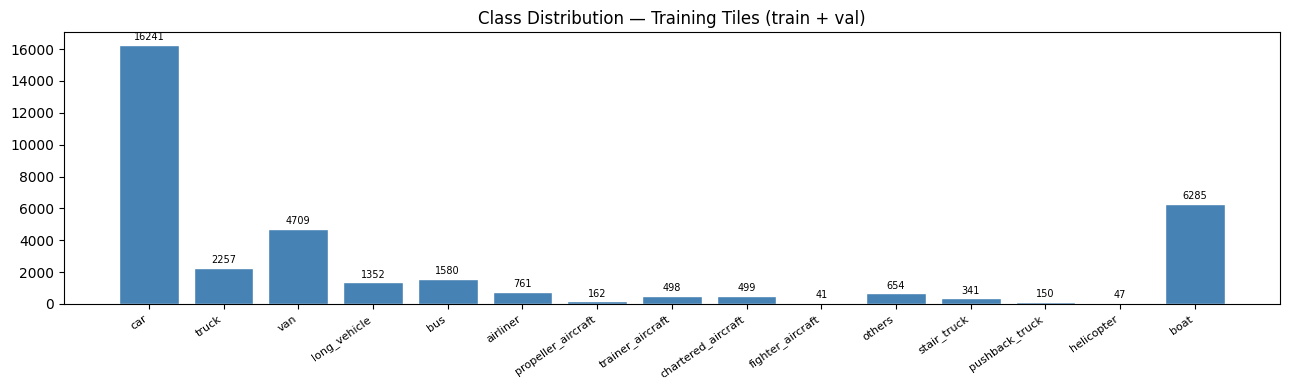

  Saved → /content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Object-detection-using-YOLOv12/Preprocessed/class_distribution.png


In [16]:
counts = collections.Counter()
for split_dir in ['train', 'val']:
    for f in (Path(PREP)/split_dir/'labels').glob('*.txt'):
        for line in f.read_text().splitlines():
            if line.strip(): counts[int(line.split()[0])] += 1

ids  = sorted(counts)
vals = [counts[i] for i in ids]
fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar([CLASS_NAMES[i] for i in ids], vals, color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%d', fontsize=7, padding=2)
ax.set_title('Class Distribution — Training Tiles (train + val)', fontsize=12)
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(f"{PREP}/class_distribution.png", dpi=150); plt.show()
print(f"  Saved → {PREP}/class_distribution.png")

**TRAIN YOLOv12 MODEL**

In [ ]:
print("TRAINING...")
model = YOLO("yolo12s.pt")
model.train(
    data      = yaml_path,
    epochs    = 30,
    imgsz     = 1024,
    batch     = 8,
    patience  = 7,
    optimizer = "AdamW",
    lr0       = 1e-3,
    cos_lr    = True,
    mosaic    = 0.5,
    degrees   = 180,
    flipud    = 0.5,
    cache     = "ram",
    resume    = True,
    project   = f"{PREP}/runs",
    name      = "simd_yolov12",
    exist_ok  = True,
)


TRAINING...
Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Object-detection-using-YOLOv12/Preprocessed/simd.yaml, degrees=180, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0

**TRAINING CURVES**

In [ ]:
csv = Path(f"{PREP}/runs/simd_yolov12/results.csv")
df  = pd.read_csv(csv); df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("YOLOv12 — Training Results", fontsize=13, fontweight="bold")

for col, lbl, c in [("train/box_loss","Box","royalblue"),
                     ("train/cls_loss","Class","tomato"),
                     ("train/dfl_loss","DFL","seagreen")]:
    if col in df: axes[0].plot(df[col], label=lbl, color=c)
axes[0].set_title("Train Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

for col, lbl, c in [("val/box_loss","Box","royalblue"),
                     ("val/cls_loss","Class","tomato")]:
    if col in df: axes[1].plot(df[col], label=lbl, color=c)
axes[1].set_title("Val Loss"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

for col, lbl, c in [("metrics/mAP50(B)","mAP@0.5","darkorange"),
                     ("metrics/mAP50-95(B)","mAP@0.5:95","purple")]:
    if col in df: axes[2].plot(df[col], label=lbl, color=c)
axes[2].set_title("mAP"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PREP}/training_curves.png", dpi=150); plt.show()
print(f"  Saved → {PREP}/training_curves.png")


**Test**

In [ ]:
best  = f"{PREP}/runs/simd_yolov12/weights/best.pt"
model = YOLO(best)

test_imgs = list((Path(PREP)/'test'/'images').glob('*.jpg'))
results   = model.predict(
    source   = str(Path(PREP)/'test'/'images'),
    imgsz    = 1024,
    conf     = 0.25,
    save     = True,
    project  = f"{PREP}/runs",
    name     = "simd_test",
    exist_ok = True,
    verbose  = False,
)

**Count detections per class**

In [ ]:
det_counts = {name: 0 for name in CLASS_NAMES}
for r in results:
    if r.boxes is not None:
        for cid in r.boxes.cls.cpu().numpy():
            det_counts[CLASS_NAMES[int(cid)]] += 1

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(det_counts.keys(), det_counts.values(), color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%d', fontsize=7, padding=2)
ax.set_title(f'Test Set — Detections per Class  ({len(test_imgs)} tiles)', fontsize=12)
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(f"{PREP}/test_detections.png", dpi=150); plt.show()
print(f"  Total tiles     : {len(test_imgs)}")
print(f"  Total detections: {sum(det_counts.values())}")
print(f"  Saved → {PREP}/test_detections.png")s

**EVALUATE**

In [ ]:
m = model.val(data=yaml_path, split="test", imgsz=1024)

print(f"\n{'='*40}")
print(f"  mAP@0.5      : {m.box.map50:.4f}")
print(f"  mAP@0.5:0.95 : {m.box.map:.4f}")
print(f"  Precision    : {m.box.mp:.4f}")
print(f"  Recall       : {m.box.mr:.4f}")
print(f"{'='*40}")



In [ ]:
if hasattr(m.box, 'ap_class_index') and m.box.ap_class_index is not None:
    ap_cls  = [CLASS_NAMES[i] for i in m.box.ap_class_index]
    ap_vals = m.box.ap50
    fig, ax = plt.subplots(figsize=(13, 5))
    bars = ax.barh(ap_cls, ap_vals, color='steelblue', edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=3)
    ax.set_title('Per-Class AP@0.5 — Test Set', fontsize=12)
    ax.set_xlim(0, 1.05); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PREP}/per_class_ap.png", dpi=150); plt.show()
    print(f"  Saved → {PREP}/per_class_ap.png")

**PR CURVE + F1 CURVE**

In [ ]:
run_dir = Path(PREP)/'runs'/'simd_yolov12'
for fname, title in [
    ('PR_curve.png',  'Precision-Recall Curve — Val Set'),
    ('F1_curve.png',  'F1-Confidence Curve — peak = best conf threshold'),
]:
    p = run_dir / fname
    if p.exists():
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.imshow(plt.imread(str(p))); ax.axis('off')
        ax.set_title(title, fontsize=12, fontweight='bold')
        plt.tight_layout(); plt.show()

**CONFUSION MATRIX**

In [ ]:
cm_path = Path(f"{PREP}/runs/simd_yolov12/confusion_matrix_normalized.png")
if cm_path.exists():
    cm_img = cv2.imread(str(cm_path))
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(cm_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Confusion Matrix (Normalized) — Validation set (from training)', fontsize=13)
    plt.tight_layout(); plt.show()
    print(f"  Displayed → {cm_path}")

**GROUND TRUTH vs PREDICTION**

In [ ]:
save_dir = Path(PREP)/'predictions'; save_dir.mkdir(exist_ok=True)
# only sample tiles that have at least one labelled object
test_tiles_with_labels = [
    f for f in (Path(PREP)/'test'/'images').glob('*.jpg')
    if (Path(PREP)/'test'/'labels'/f"{f.stem}.txt").exists()
    and (Path(PREP)/'test'/'labels'/f"{f.stem}.txt").stat().st_size > 0
]
samples = random.sample(test_tiles_with_labels, min(4, len(test_tiles_with_labels)))

for img_path in samples:
    img  = cv2.imread(str(img_path))
    rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]
    gt_lbls = read_labels(Path(PREP)/'test'/'labels'/f"{img_path.stem}.txt")
    res = model.predict(img_path, imgsz=1024, conf=0.25, verbose=False)[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(img_path.name, fontsize=9)
    for ax, title in zip(axes, ['Ground Truth', 'Prediction']):
        ax.imshow(rgb); ax.axis('off'); ax.set_title(title, fontsize=10)

    for (c, cx, cy, bw, bh) in gt_lbls:
        x1, y1 = (cx - bw/2)*w, (cy - bh/2)*h
        color = CMAP(int(c))[:3]
        axes[0].add_patch(patches.FancyBboxPatch(
            (x1, y1), bw*w, bh*h, linewidth=1.5,
            edgecolor=color, facecolor='none', boxstyle='square,pad=0'))
        axes[0].text(x1, y1 - 3, CLASS_NAMES[int(c)],
                     color='white', fontsize=6, fontweight='bold',
                     bbox=dict(facecolor=color, alpha=0.75, pad=1, edgecolor='none'))

    if res.boxes is not None and len(res.boxes):
        for box, score, cid in zip(res.boxes.xywhn.cpu().numpy(),
                                    res.boxes.conf.cpu().numpy(),
                                    res.boxes.cls.cpu().numpy()):
            cx, cy, bw, bh = box
            x1, y1 = (cx - bw/2)*w, (cy - bh/2)*h
            color = CMAP(int(cid))[:3]
            axes[1].add_patch(patches.FancyBboxPatch(
                (x1, y1), bw*w, bh*h, linewidth=1.5,
                edgecolor=color, facecolor='none', boxstyle='square,pad=0'))
            axes[1].text(x1, y1 - 3, f"{CLASS_NAMES[int(cid)]} {score:.2f}",
                         color='white', fontsize=6, fontweight='bold',
                         bbox=dict(facecolor=color, alpha=0.75, pad=1, edgecolor='none'))

    plt.tight_layout()
    plt.savefig(str(save_dir/f"gt_vs_pred_{img_path.name}"), dpi=120, bbox_inches='tight')
    plt.show(); plt.close()

**Visualize Test Results**

In [ ]:
samples = random.sample(list((Path(PREP)/'test'/'images').glob('*.jpg')), 8)

for img_path in samples:
    img = cv2.imread(str(img_path))
    res = model.predict(img_path, imgsz=1024, conf=0.25, verbose=False)[0]
    if res.boxes is None or len(res.boxes) == 0: continue

    rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(rgb)

    for box, score, cid in zip(res.boxes.xywhn.cpu().numpy(),
                                res.boxes.conf.cpu().numpy(),
                                res.boxes.cls.cpu().numpy()):
        cx, cy, bw, bh = box
        x1, y1 = (cx - bw/2)*w, (cy - bh/2)*h
        color  = CMAP(int(cid))[:3]
        ax.add_patch(patches.FancyBboxPatch(
            (x1, y1), bw*w, bh*h, linewidth=1.5,
            edgecolor=color, facecolor='none', boxstyle='square,pad=0'))
        ax.text(x1, y1 - 3, f"{CLASS_NAMES[int(cid)]} {score:.2f}",
                color='white', fontsize=6, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.75, pad=1, edgecolor='none'))

    ax.axis('off'); ax.set_title(img_path.name, fontsize=8)
    fig.savefig(str(save_dir / img_path.name), dpi=120, bbox_inches='tight')
    plt.show(); plt.close()

print(f"  Predictions saved → {save_dir}")